In [3]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull,QhullError
from scipy.spatial import cKDTree


In [4]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [5]:
def empty_lattice(lc, n1, n2, n3,lattice_big):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice = extendfcc(fccbasis(lc), lc, n1, n2, n3)
    mid_position = np.mean(lattice, axis=0)
    lattice=np.round(lattice-mid_position,6)
    x_max, y_max, z_max = np.max(lattice, axis=0)
    x_min, y_min, z_min = np.min(lattice, axis=0)
    # lattice=np.round(lattice-mid_position,6)
    # lattice=order_pos(lattice)
    lattice = lattice[
        np.where(
            (lattice[:, 0] >= x_min)
            & (lattice[:, 0] <= x_max)
            & (lattice[:, 1] >= y_min)
            & (lattice[:, 1] <= y_max)
            & (lattice[:, 2] >= z_min)
            & (lattice[:, 2] <= z_max)
        )
    ]
    return order_pos(lattice)


def order_pos(lattice, mid_position=None):
    if mid_position is None:
        mid_position = np.mean(lattice, axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist = np.round(cdist([mid_position], lattice), 6)
    dist_dict = Counter(dist[0])
    sorted_count = sorted(dist_dict.items(), key=lambda x: x[0], reverse=False)
    record = []
    ordered_particle = []
    for i in range(len(sorted_count)):
        record.extend(np.where(dist == sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)


def particles_encode_gen_no_oblate(lc, lattice_big, num_atoms=None, max_num_atoms=None):
    if num_atoms == None:
        assert (
            max_num_atoms != None
        ), "Please provide the maximum number of atoms in the lattice."
        num_atoms = random.randint(12, max_num_atoms)
    # min_num_points=num_atoms
    num_lattice = max_num_atoms // 2
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    num_points = 0
    # transfer points to the big lattice
    indices = []
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(
            np.where(
                np.all(np.isclose(lattice_big, lattice_big[i], rtol=1e-3), axis=1)
            )[0]
        )
    return lattice_big[indices]


# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc, lattice_big, num_atoms=None, max_num_atoms=None):
    if num_atoms == None:
        # assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms = random.randint(12, max_num_atoms)
    num_lattice = max_num_atoms // 2
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    # min_num_points=num_atoms

    # print(f"length={np.mean(lattice_big,axis=0)}")
    # times=random.randint(1,3)
    # the extreme case is that the particle has only one layer of unit cells, which has the dimension: np.sqrt(n_max**3)*np.sqrt(n_max**3)*1
    n1 = random.randint(1, np.floor(np.sqrt(n_max**3)))
    n2 = random.randint(1, np.floor(np.sqrt(n_max**3)))
    n3 = random.randint(1, np.floor(np.sqrt(n_max**3)))
    lattice = empty_lattice(lc, n1, n2, n3,lattice_big)
    num_points = len(lattice)
    # this is too strong
    while num_points < num_atoms * 2 or n1 * n2 * n3 > n_max**3:
        n1 = random.randint(1, np.floor(np.sqrt(n_max**3)))
        n2 = random.randint(1, np.floor(np.sqrt(n_max**3)))
        n3 = random.randint(1, np.floor(np.sqrt(n_max**3)))
        lattice = empty_lattice(lc, n1, n2, n3,lattice_big)
        num_points = len(lattice)
    lattice = lattice[:num_atoms]
        # print((num_points,n1,n2,n3,num_atoms))
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice

    return lattice


def ini_population(
    lc, population_size, lattice_big, num_atoms=None, max_num_atoms=None
):
    generations = []
    n = 0
    while n < population_size:
        particle = particles_encode_gen(
            lc,
            lattice_big=lattice_big,
            num_atoms=num_atoms,
            max_num_atoms=max_num_atoms,
        )
        # print(particle)
        generations.append(particle)
        n += 1
    return generations


def fitness(particle, descriptors: dict):
    atom = Atoms(positions=particle, symbols=["Pt"] * len(particle))
    cluster_descriptors = descriptor_table(
        atom, all=False, descriptors=list(descriptors.keys()) + ["flattening_moment"]
    )
    true_dis=[]
    for k in descriptors.keys():
        if k!='ellipsoid':
            true_dis.append(descriptors[k])
        else:
            true_dis.append(descriptors[k][0])
            true_dis.append(descriptors[k][1])
            true_dis.append(descriptors[k][2])
    true_dis=np.array(true_dis)
    # print(true_dis)
    pred_dis = np.array([cluster_descriptors[k] for k in list(cluster_descriptors.keys())[:-1]])
    # print(pred_dis)
    # MSE
    # np.sum((true_dis-pred_dis)**2)
    x = np.sort(np.abs(pred_dis / true_dis - 1))
    if cluster_descriptors["flattening_moment"] > 1:
        sim = (
            np.max(np.abs(1 - pred_dis / true_dis))
            * 10 ** cluster_descriptors["flattening_moment"]
        )
    else:
        sim = np.mean(np.power(1 - pred_dis / true_dis, 2))
    return sim, pred_dis




def parents(population, fitness_values, tol=1e5):
    fitness_values = np.array(fitness_values)
    ranking = ranking_fitness(fitness_values)
    prob = normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current = 0
    index = 0
    # for i in range(len(population)):
    while index < tol:
        i = random.randint(0, len(population) - 1)
        index += 1
        if random.uniform(0, 1) <= prob[i]:
            return list(population[i])
        if index == tol:
            raise Exception("exceed the maximum try times!")


def ranking_fitness(fitness_values):
    fitness_ranking = np.zeros(len(fitness_values))
    fitness_dict = Counter(fitness_values)
    fitness_ordered = sorted(fitness_dict.keys(), reverse=False)
    rank = 1
    for i in range(len(fitness_ordered)):
        indices = np.where(np.array(fitness_values) == fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j] = rank
        rank += 1
    return fitness_ranking


def probability_selection(fitness_ranking):
    R = len(fitness_ranking)
    lamb = np.log(10) / (max(fitness_ranking) - min(fitness_ranking))
    # print(lamb)
    z = np.array([np.exp(-lamb * r) for r in fitness_ranking])
    z_sum = np.sum(z)
    return z / z_sum


def normalized_p(fitness_ranking):
    p = probability_selection(fitness_ranking)
    return (p - np.min(p)) / (np.max(p) - np.min(p))


def atom_cut_up_down_center(particle, theta, phi, lc):
    def normal_vector(center, theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    num_atoms = len(particle)
    particle = np.array(particle)
    if len(particle) < 5:
        print("Warning particle is less than 5 atoms")
        return particle, particle
    center = np.mean(particle, axis=0)
    closest_index = np.where(
        np.all(np.isclose(center, particle, rtol=lc / (1.8 * np.sqrt(2))), axis=1)
    )[0][0]
    particle_shift = particle - particle[closest_index]
    center = np.mean(particle_shift, axis=0)
    normal = normal_vector(center, theta, phi)
    trancate_up_particle = []
    trancate_down_particle = []
    for pos in particle_shift:
        if normal[0] * (pos[0] - center[0]) + normal[1] * (pos[1] - center[1]) + normal[
            2
        ] * (pos[2] - center[2]) >= -lc / np.sqrt(2):
            trancate_up_particle.append([pos[0], pos[1], pos[2]])
        if normal[0] * (pos[0] - center[0]) + normal[1] * (pos[1] - center[1]) + normal[
            2
        ] * (pos[2] - center[2]) <= lc / np.sqrt(2):
            trancate_down_particle.append([pos[0], pos[1], pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_up_particle), np.array(trancate_down_particle)


def atom_trancate_center(particle, theta, phi):
    def normal_vector(center, theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    particle = np.array(particle)
    center = np.mean(particle, axis=0)
    normal = normal_vector(center, theta, phi)
    trancate_particle = []
    for pos in particle:
        if (
            normal[0] * (pos[0] - center[0])
            + normal[1] * (pos[1] - center[1])
            + normal[2] * (pos[2] - center[2])
            >= 0
        ):
            trancate_particle.append([pos[0], pos[1], pos[2]])

    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return trancate_particle


def atom_trancate_arbi(particle, theta, phi):
    def normal_vector(center, theta, phi):
        return np.array(
            [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
        )

    num_atoms = len(particle)
    particle = np.array(particle)
    center_get = np.mean(particle, axis=0)
    particle_vote = particle.copy()
    if [center_get] not in particle_vote:
        np.vstack((particle_vote, center_get))
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:
    center = random.choice(particle_vote)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal = normal_vector(center, theta, phi)
    trancate_particle = []
    for pos in particle:
        if (
            normal[0] * (pos[0] - center[0])
            + normal[1] * (pos[1] - center[1])
            + normal[2] * (pos[2] - center[2])
            >= 0
        ):
            trancate_particle.append([pos[0], pos[1], pos[2]])
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    # if len(trancate_particle)<5:
    #     trancate_particle=[]
    #     for pos in particle:
    #         if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
    #             trancate_particle.append([pos[0],pos[1],pos[2]])
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    return trancate_particle


def crossover(lc, parent1, parent2, cross_over_rate=0.6):
    def remove_duplicates(particle, lc):
        duplicates = []
        index_get = []
        for i in range(len(particle)):
            index = np.where(
                np.isclose(cdist([particle[i]], particle)[0], 0, atol=1e-2)
            )[0]
            if len(index) > 1:
                duplicates.extend(index[1:])
            if index[0] not in duplicates:
                index_get.append(index[0])
        return np.array([particle[i] for i in index_get])

    if random.random() < cross_over_rate:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        try:
            parent1_up, parent1_down = atom_cut_up_down_center(parent1, theta, phi, lc)
            parent2_up, parent2_down = atom_cut_up_down_center(parent2, theta, phi, lc)
        except:
            return parent1, parent2
        parent1 = np.vstack((parent1_up, parent2_down))
        parent2 = np.vstack((parent1_down, parent2_up))
        parent1 = remove_duplicates(parent1, lc)
        parent2 = remove_duplicates(parent2, lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1, parent2
    else:
        return parent1, parent2


def mutation(particle, lc, lattice_big, max_num_atoms, mutation_rate=0.3):
    mr = random.uniform(0, 1)
    num_atoms = len(particle)

    # if mr <= mutation_rate/3:  # / 2:
    #     # renum = 0
    #     # theta = random.uniform(0, np.pi)
    #     # phi = random.uniform(0, 2 * np.pi)
    #     # particle_update = atom_trancate_center(particle, theta, phi)
    #     # while len(particle_update) < 5 and renum < 5:
    #     #     theta = random.uniform(0, np.pi)
    #     #     phi = random.uniform(0, 2 * np.pi)
    #     #     # if renum==0:
    #     #     #     print("no good 1")
    #     #     particle_update = atom_trancate_center(particle, theta, phi)
    #     #     renum += 1
    if mr <= mutation_rate / 2: #and mr <= mutation_rate * 2 / 3:
        renum = 0
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        particle_update = atom_trancate_arbi(particle, theta, phi)
        while len(particle_update) < 5 and renum < 5:
            theta = random.uniform(0, np.pi)
            phi = random.uniform(0, 2 * np.pi)
            particle_update = atom_trancate_arbi(particle, theta, phi)
            renum += 1
    elif mr > mutation_rate * 1/2 and mr <= mutation_rate:
        # 2. initialization of populations
        particle_update = ini_population(
            lc=lc,
            population_size=1,
            lattice_big=lattice_big,
            max_num_atoms=max_num_atoms,
            num_atoms=None,
        )[0]

    else:
        particle_update = particle
    return particle_update


def convex_particle(particle, lattice_big, lc):
    indices = []
    try:
        hull = ConvexHull(particle)
    except QhullError:
        # print("less than 3 dimensions")
        # print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points, hull, lc):
            indices.extend(
                np.where(np.all(np.isclose(points, lattice_big, rtol=1e-1), axis=1))[0]
            )
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices])


def is_point_in_hull(point, hull, lc):
    equations = hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(
        np.dot(equations[:, :-1], point) + equations[:, -1] <= lc / (2 * np.sqrt(2))
    )


def find_most_similar(population, individual, crowding_distance=0.1):
    return np.array(
        [
            min(
                population,
                key=lambda x: calculate_similarity(x, individual, crowding_distance),
            )
        ]
    )[0]


def chamfer_distance(point_cloud_A, point_cloud_B):
    tree_A = cKDTree(point_cloud_A)
    tree_B = cKDTree(point_cloud_B)

    dist_A_to_B, _ = tree_A.query(point_cloud_B, k=1)
    dist_B_to_A, _ = tree_B.query(point_cloud_A, k=1)

    chamfer_dist = np.mean(dist_A_to_B) + np.mean(dist_B_to_A)

    return chamfer_dist


def align_point_clouds_pca(particle1, particle2):
    # align particle1 to particle2
    # Center the point clouds
    source_centered = particle1 - np.mean(particle1, axis=0)
    target_centered = particle2 - np.mean(particle2, axis=0)

    # Perform PCA
    source_pca = PCA(n_components=3).fit(source_centered)
    target_pca = PCA(n_components=3).fit(target_centered)

    # Align principal components
    R = np.dot(target_pca.components_.T, source_pca.components_)
    aligned_source = np.dot(source_centered, R.T) + np.mean(particle2, axis=0)

    return aligned_source


def sharing_function(ind1, ind2, niche_radius, alpha):
    distance = calculate_similarity(ind1, ind2, niche_radius)
    if distance < niche_radius:
        return 1 - (distance / niche_radius) ** alpha
    else:
        return 0


def calculate_similarity(ind1, ind2, crowding_distance=0.1):
    # atoms1 = Atoms(positions=ind1, symbols=["Pt"] * len(ind1))
    # atoms2 = Atoms(positions=in2, symbols=["Pt"] * len(in2))
    # des_atoms1 = descriptor_table(atoms1)
    # score1 = np.array(np.array([des_atoms1[k] for k in des_atoms1.keys()]))
    # des_atoms2 = descriptor_table(atoms2)
    # score2 = np.array([des_atoms2[k] for k in des_atoms2.keys()])
    # return np.mean((score1 - score2) ** 2)
    ind1 = align_point_clouds_pca(ind1, ind2)
    dist = chamfer_distance(ind1, ind2)

    return dist / crowding_distance


def shared_fitness_value(individual, descriptor, population, niche_radius, alpha):
    fitnessvalue, predict_value = fitness(individual, descriptor)
    sharing_sum = sum(
        sharing_function(individual, other, niche_radius, alpha) for other in population
    )
    return fitnessvalue / sharing_sum, predict_value


def fitness_sharing(population, descriptor, niche_radius, alpha):
    shared_fitness = []
    predict_values = []
    for individual in population:
        fitness_value, predict_value = shared_fitness_value(
            individual, descriptor, population, niche_radius, alpha
        )
        shared_fitness.append(fitness_value)
        predict_values.append(predict_value)
    return shared_fitness, predict_values


# def write_file(Atoms_list, foldername):
#     if not os.path.isdir(foldername):
#         os.mkdir(foldername)
#     n = 1
#     for atoms in Atoms_list:
#         write(f"{foldername}/individual_{n}.xyz", atoms, format="xyz")
#         n += 1


def genetic_algorithm(
    max_num_atoms=200,
    generations=40,
    population_size=100,
    lc=3.77,
    cross_over_rate=0.3,
    elite_fraction=0.05,
    initial_crowding_distance=0.1,
    niche_radius=0.1,
    alpha=1,
    initial_mutation_rate=1,
    mutation_rate_decay=0.9,
    descriptors={"flattening_moment": 1, "atom_number": 55}
    # "CN1":6,
    # "CN2":1.5,
    # "CN3":2,
    # "CN4":5
):
    # 1. set up parameters

    print(descriptors)
    num_lattice = max_num_atoms // 2  # since one unit cell of fcc lattice has 2 atoms
    n_max = int(np.ceil(np.cbrt(num_lattice)))
    lattice_big = extendfcc(fccbasis(lc), lc,  int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3)))
    lattice_big=lattice_big-np.mean(lattice_big,axis=0)

    # 2. initialization of populations
    populations = ini_population(
        lc=lc,
        population_size=population_size,
        lattice_big=lattice_big,
        num_atoms=None,
        max_num_atoms=max_num_atoms,
    )
    mutation_rate = initial_mutation_rate
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record = populations.copy()
    fitness_record = []
    best_particle = []
    # 3. calculate fitness for populations
    fitness_values = fitness_sharing(populations, descriptors, niche_radius, alpha)[0]
    # print(len(fitness_values),len(populations))
    # 4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (1). generate new populations
        new_populations = []
        fit_pop = dict()
        for i in range(len(populations)):
            fit_pop[fitness_values[i]] = populations[i]
        sorted_population = [
            sorted(fit_pop.items(), key=lambda item: item[0], reverse=False)[i][1]
            for i in range(len(fit_pop))
        ]
        # print(population_size,elite_fraction)
        num_elites = int(population_size * elite_fraction)
        elites = sorted_population[:num_elites]
        # check duplicates, if duplicates exist, then generate a new structure
        num_residual = population_size - num_elites
        n = 0
        while n != num_residual:
            # [1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1 = parents(populations, fitness_values)
            parent2 = parents(populations, fitness_values)
            parent1 = np.array(parent1)
            parent2 = np.array(parent2)
            # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            # [2]. crossover and mutation to generate offsprings
            children1, children2 = crossover(
                lc, parent1, parent2, cross_over_rate=cross_over_rate
            )

            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1 = mutation(
                children1, lc, lattice_big, max_num_atoms, mutation_rate=mutation_rate
            )
            children2 = mutation(
                children2, lc, lattice_big, max_num_atoms, mutation_rate=mutation_rate
            )
            # convex hull

            children1 = convex_particle(children1, lattice_big, lc)
            children2 = convex_particle(children2, lattice_big, lc)
            if len(children1) == 0 or len(children2) == 0:
                continue
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1, children2])
            n += 2
            if num_residual - n == 1:
                parent1 = parents(populations, fitness_values)
                parent2 = parents(populations, fitness_values)
                parent1 = np.array(parent1)
                parent2 = np.array(parent2)
                children1, children2 = crossover(
                    lc, parent1, parent2, cross_over_rate=cross_over_rate
                )
                children1 = mutation(
                    children1,
                    lc,
                    lattice_big,
                    max_num_atoms,
                    mutation_rate=mutation_rate,
                )
                children2 = mutation(
                    children2,
                    lc,
                    lattice_big,
                    max_num_atoms,
                    mutation_rate=mutation_rate,
                )
                children1 = convex_particle(children1, lattice_big, lc)
                children2 = convex_particle(children2, lattice_big, lc)
                if len(children1) == 0 or len(children2) == 0:
                    continue
                new_populations.extend([children1])
                n += 1
        new_populations.extend(elites)
        crowding_distance = initial_crowding_distance
        for child in new_populations:
            try:
                most_similar_individual = find_most_similar(
                    populations, child, crowding_distance
                )
                if (
                    fitness(child, descriptors)[0]
                    <= fitness(most_similar_individual, descriptors)[0]
                ):
                    index = 0
                    for ind in populations:
                        if np.array_equal(ind, most_similar_individual):
                            break
                        index += 1
                    populations.pop(index)
                    populations.append(child)
            except:
                continue
        # for child in new_populations:
        #     print(f"child={populations}")
        #     most_similar_individual = find_most_similar(populations, child)
        #     # print(f"most_similar_individual={most_similar_individual.shape}")
        #     # print(f"child={child.shape}")

        #     if fitness(child,descriptors)[0] <= fitness(most_similar_individual,descriptors)[0]:

        #         populations = [ind for ind in populations if not np.array_equal(ind, most_similar_individual)]
        #         new_population2.append(child)
        #     else:
        #         new_population2.append(most_similar_individual)
        # new_population2 = new_population2[:population_size]
        # new_populations.extend(elites)
        # print(f"new_populations={len(new_populations)}")

        # (2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values = []
        predict_values = []
        # for particle in populations:
        # print(f"genome={genome}")
        # fitness_cal = fitness(particle, descriptors)
        fitness_values, predict_values = fitness_sharing(
            populations, descriptors, initial_crowding_distance, alpha
        )
        # fitness_values.append(fitness_cal[0])
        # predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        # (3). find the best solution
        # [1]. best fitness value and prediction
        fitness_value_sort=sorted(fitness_values)
        print(f"fitness_value_sort={fitness_value_sort}")
        quater_fitness_index=np.where(np.array(fitness_values)<=fitness_value_sort[int(len(fitness_values)*0.75)])[0][0]
        print(f"quater_fitness_index={quater_fitness_index}")
        best_fitness = min(fitness_values)
        ave_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        # best_predict = predict_values[fitness_values.index(best_fitness)]
        predict_quater=predict_values[quater_fitness_index]

        best_index = fitness_values.index(best_fitness)
        mean_predict = np.mean(predict_values)
        # [2]. reconstruct the best solution from codes using new_populations.
        particle = populations[best_index]
        # best_clustering_energy=min(clustering_energy_values)
        # [3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle, symbols=["Pt"] * len(particle)))
        fitness_record.append(ave_fitness)  # dong
        mutation_rate *= mutation_rate_decay
        # [4]. print output
        print(
            f"Generation{generation}: Finess={np.round(np.mean(fitness_values),3)}+/-{np.round(np.std(fitness_values),3)} Predict_Q3={predict_quater}"
        )

        # [6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    # 4. record the best solution
    best_index = fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    best_atom = Atoms(positions=best_solution, symbols=["Pt"] * len(best_solution))
    last_population = populations
    last_atom_list = []
    for i in range(len(last_population)):
        last_atom_list.append(
            Atoms(
                positions=last_population[i], symbols=["Pt"] * len(last_population[i])
            )
        )
    ini_atom_list = []
    for i in range(len(ini_population_record)):
        ini_atom_list.append(
            Atoms(
                positions=ini_population_record[i],
                symbols=["Pt"] * len(ini_population_record[i]),
            )
        )
    return fitness_record, last_atom_list, ini_atom_list, best_particle
    # def genome(num_atoms):
    #     np.randomduplicates exist, then generate a new structure



In [6]:
np.sort([1,3,4,3,2,1])[-2]

3

In [77]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]


ini_configurations={
        "max_num_atoms":200,
        "generations":10,
        "population_size":10,
        "lc":3.77,
        "cross_over_rate":0.6,
        "elite_fraction":0.1,
        "initial_crowding_distance":0.1,
        "niche_radius":0.1,
        "alpha":1,
        "initial_mutation_rate":1,
        "mutation_rate_decay":0.993,
        "descriptors":{
                "CN1":8.47,
                # "CN2":3.11,
                # "CN3":11.29,
                # "CN4":5.22,	
                #"flattening_pca":1,
                "diameter_2radius":15.08,
                "surface ratio":1
                #"atom_number":85}
                #"Departure from sphere(moment)":0.0001,
                }   
      }

for i in range(1):
    # best_atom=None
    # fitness_record=None
    # fitness_value=None
    # best_particle=None
    # last_atom_list=None
    # ini_atom_list=None
    fitness_record,last_atom_list,ini_atom_list,best_particle=genetic_algorithm(max_num_atoms=ini_configurations["max_num_atoms"],
                                                                                generations=ini_configurations["generations"],
                                                                                population_size=ini_configurations["population_size"],
                                                                                lc=ini_configurations["lc"],
                                                                                niche_radius=ini_configurations["niche_radius"],
                                                                                alpha=ini_configurations["alpha"],
                                                                                initial_mutation_rate=ini_configurations["initial_mutation_rate"],
                                                                                mutation_rate_decay=ini_configurations["mutation_rate_decay"],
                                                                                cross_over_rate=ini_configurations["cross_over_rate"],
                                                                                elite_fraction=ini_configurations["elite_fraction"],
                                                                                descriptors=ini_configurations["descriptors"])
    # best_atoms.append(best_atom)
    # fitness_records.append(fitness_record)
    # fitness_values.append(fitness_value)
    # best_particles.append(best_particle)
    # last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'CN1': 8.47, 'diameter_2radius': 15.08, 'surface ratio': 1}


  0%|          | 0/10 [00:00<?, ?it/s]

fitness_value_sort=[0.017274611822918413, 0.02672055604659319, 0.04125256696986897, 0.050716946128135605, 0.05161432371202992, 0.0589882807633295, 0.07151124157191034, 0.1442468495834146, 3.42835574639288, 9.826480528036976]
quater_fitness_index=0
Generation0: Finess=1.372+/-2.992 Predict_Q3=[ 7.93 19.44  0.81]
fitness_value_sort=[0.017274611822918413, 0.02672055604659319, 0.04004359156456376, 0.040121255176728786, 0.04409611653153867, 0.05161432371202992, 0.07151124157191034, 0.1442468495834146, 3.116996363737358, 9.826480528036976]
quater_fitness_index=0
Generation1: Finess=1.338+/-2.973 Predict_Q3=[ 8.   20.29  0.82]
fitness_value_sort=[0.01652820563821552, 0.023554977559874485, 0.02672055604659319, 0.031115652011729906, 0.04004359156456376, 0.040121255176728786, 0.04409611653153867, 0.05161432371202992, 0.1442468495834146, 3.116996363737358]
quater_fitness_index=0
Generation2: Finess=0.354+/-0.922 Predict_Q3=[ 8.   20.29  0.82]
fitness_value_sort=[0.013359820770577317, 0.0164524599

In [8]:
def plot_sphere(center:np.array,radius:float,ax)->None:
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:20j]
    x = radius*np.cos(u)*np.sin(v)+center[0]
    y = radius*np.sin(u)*np.sin(v)+center[1]
    z = radius*np.cos(v)+center[2]
    ax.plot_surface(x, y, z, cmap='viridis', alpha=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
def bond_length(xyz_filename:str):
    xyz=np.loadtxt(xyz_filename,skiprows=2,usecols=(1,2,3))
    distance=cdist([xyz[0]],xyz)
    dist=np.sort(distance[0])
    return np.round(dist[1],2)
def atom_model(xyz_filename:str,ax):
    xyz=np.loadtxt(xyz_filename,skiprows=2,usecols=(1,2,3))
    for i in range(len(xyz)):
        plot_sphere(xyz[i],1.5,ax)

# 1. intialization

In [7]:
num_lattice=200//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lc=3.77
max_num_atoms=200
num_lattice = max_num_atoms // 2  # since one unit cell of fcc lattice has 2 atoms
n_max = int(np.ceil(np.cbrt(num_lattice)))
lattice_big = extendfcc(fccbasis(lc), lc, int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3)), int(np.sqrt(n_max**3)))
lattice_big=lattice_big-np.mean(lattice_big,axis=0)
particles=ini_population(lc=3.77,
                    population_size=100,
                    lattice_big=lattice_big,
                    num_atoms=None,max_num_atoms=200)


In [8]:
# particles

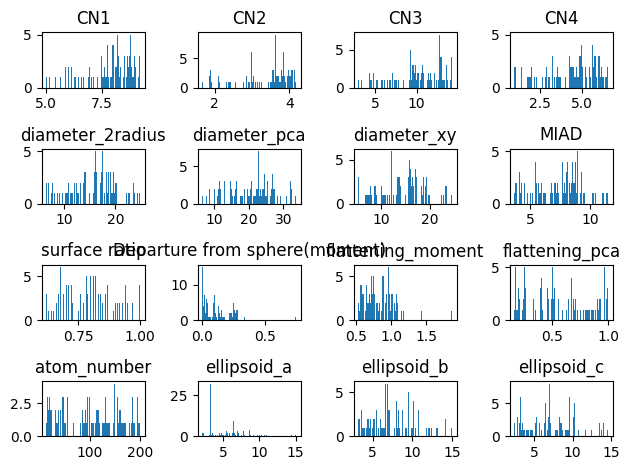

In [9]:
atom_list = []
for i in range(len(particles)):
    atom_list.append(
        Atoms(
            positions=particles[i],
            symbols=["Pt"] * len(particles[i]),
        )
    )

particles_descriptors=[]
bas=[]

for i in range(len(atom_list)):
    particles_descriptors.append(descriptor_table(atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100,grid=False)
plt.tight_layout()

In [10]:
pdes

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number,ellipsoid_a,ellipsoid_b,ellipsoid_c
0,8.47,3.69,12.43,5.32,13.96,19.65,13.32,7.18,0.78,0.001753,1.05,1.00,103,6.588309,6.910735,6.897540
1,6.17,2.35,5.91,2.17,9.11,12.86,9.11,4.51,0.96,0.015983,1.09,0.90,23,3.617718,4.267886,4.033176
2,5.41,2.12,4.35,1.94,7.69,11.42,7.66,4.18,1.00,0.032616,1.02,0.99,17,3.248030,3.896844,3.636480
3,7.71,3.05,9.89,4.22,11.42,18.47,11.42,5.87,0.82,0.006029,0.91,0.84,55,4.840312,5.731315,5.721814
4,8.80,4.01,12.96,6.01,18.35,25.13,16.97,8.68,0.67,0.103873,0.70,0.46,160,6.519589,10.483182,9.255435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8.17,3.74,10.84,4.86,15.96,18.47,15.51,7.29,0.75,0.158057,1.43,1.00,93,5.959062,5.950352,8.415434
96,8.10,3.84,10.23,4.87,22.56,30.77,22.24,10.29,0.80,0.267809,0.56,0.18,159,3.262130,13.163878,13.468681
97,6.45,2.77,6.58,2.84,9.64,11.95,8.87,5.10,0.97,0.086858,0.87,0.50,31,3.261546,5.154273,5.157758
98,5.14,2.14,3.43,1.71,6.53,6.53,5.33,3.88,1.00,0.000000,1.00,1.00,14,3.259042,3.263256,3.261150


In [11]:
view(last_atom_list[9])

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [12]:
%matplotlib widget

In [13]:
len(pdes[pdes["flattening_moment"]==0])

0

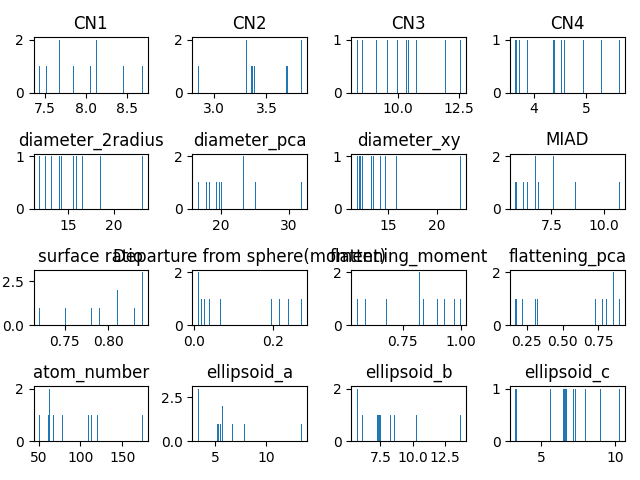

In [14]:
particles_descriptors=[]
bas=[]

for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100,grid=False)
plt.tight_layout()

In [15]:
pdes[pdes['Departure from sphere(moment)']<0.03]

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number,ellipsoid_a,ellipsoid_b,ellipsoid_c
0,7.68,3.35,10.00,4.39,11.80,18.03,11.80,6.15,0.81,0.008489,0.90,0.90,62,5.641269,5.649774,5.652741
6,7.68,2.84,9.16,3.88,12.58,16.66,12.07,5.78,0.84,0.018676,1.00,0.86,50,5.653281,5.647396,6.518001
7,8.70,3.83,12.57,5.65,15.64,23.31,14.15,7.58,0.72,0.010129,0.93,0.86,120,7.840780,7.351317,7.160610
8,8.46,3.70,11.95,5.29,16.59,23.21,14.76,7.60,0.75,0.025411,0.97,0.81,113,6.744707,8.610698,8.036060


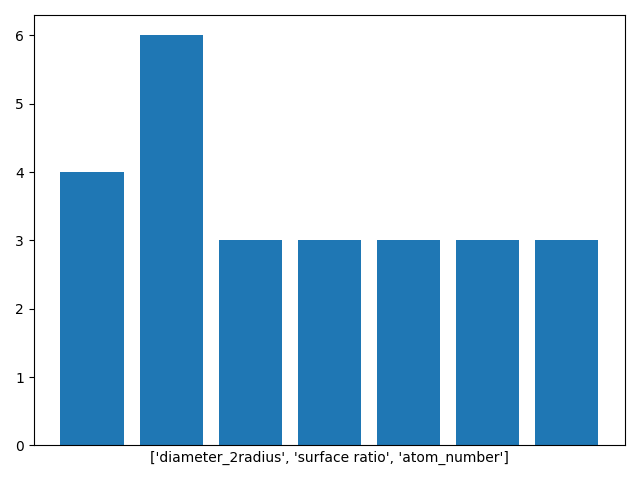

In [16]:
list_par=[]
descriptors=["diameter_2radius",
                "surface ratio",
                "atom_number"]

for i in range(pdes.shape[0]):
    dis=[]
    for d in descriptors:
        dis.append(pdes.iloc[i][d])
    list_par.append([dis])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']>10:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel(descriptors)
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [17]:
# par_dict['[7.5, 2.95, 8.77, 3.41]']
view(last_atom_list[par_dict['[[11.21, 0.86, 42.0]]']['indices'][0]],viewer='x3d')

KeyError: '[[11.21, 0.86, 42.0]]'

In [ ]:
view(last_atom_list[90],viewer='x3d')

In [ ]:
from shape_proj_util.geo_tools.convenient_datasoup import *
data=particle_database(element='Pt')
data.predefine_data(3.77)
table=data.shape_info().T



In [ ]:
table

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number
OCT_2,4.00,1.00,0.00,0.00,3.77,6.53,3.77,2.89,1.00,0.000000,1.00,1.00,6.0
OCT_3,6.32,1.89,5.05,1.89,7.54,13.06,7.54,4.16,0.95,0.000000,0.00,1.00,19.0
OCT_4,7.64,2.59,8.73,3.82,11.31,18.24,11.31,5.49,0.86,0.000000,1.00,1.00,44.0
OCT_5,8.47,3.11,11.29,5.22,15.08,25.96,15.08,6.84,0.78,0.000000,0.00,1.00,85.0
OCT_6,9.04,3.49,13.15,6.25,18.85,29.81,18.85,8.19,0.70,0.000000,1.00,1.00,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
HEX_O1_2_SQ_O2_cut_ori_100_l_2,8.44,4.66,3.21,2.86,13.81,20.30,13.59,7.03,0.73,0.050589,0.77,0.57,91.0
HEX_O1_2_SQ_O2_cut_ori_100_l_3,7.89,4.11,3.06,2.57,14.26,19.68,13.59,6.70,0.81,0.109811,0.68,0.42,70.0
HEX_O1_2_SQ_O2_cut_ori_100_l_4,7.13,2.96,2.74,5.13,12.24,15.55,11.92,6.05,0.91,0.172209,0.61,0.35,46.0
HEX_O1_2_SQ_O2_cut_ori_100_l_5,5.76,2.88,2.08,3.84,11.39,11.47,11.31,5.30,1.00,0.244533,0.56,0.24,25.0


In [ ]:
min(population, key=lambda x: calculate_similarity(x, individual))
# data.search_by_name("OCT_4")


array([ -1.32,  -0.7 ,  -3.68,  -1.93,  -3.77,  -5.18,  -3.77,  -1.33,
         0.09,   0.  ,  -1.  ,   0.  , -25.  ])

# ellipsoid

In [9]:
from shape_proj_util.geo_tools import geometry

In [10]:
view(last_atom_list[0],viewer='x3d')

In [9]:
x=np.array(geometry.ellipsoid(last_atom_list[9]))
x




ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

In [78]:
%matplotlib widget

In [113]:
# import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

def draw_ellipsoid(atoms):
    position=atoms.get_positions()
    radii=geometry.ellipsoid(atoms)
    center=radii[3]
    rotation=radii[4]
    # Create a grid of points
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    
    # Create the ellipsoid points in the local space
    x = radii[0] *  np.outer(np.sin(v), np.cos(u))
    y = radii[1] *  np.outer(np.sin(v), np.sin(u))
    z = radii[2] *  np.outer(np.cos(v), np.ones_like(u))



    
    for i in range(len(x)):
        for j in range(len(x[0])):
            # print(np.dot([x[i, j], y[i, j], z[i, j]], radii) * rotation + center)
            [x[i, j], y[i, j], z[i, j]] = np.dot(rotation,[x[i, j], y[i, j], z[i, j]]) + center

    # Plot ellipsoid
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z,  rstride=4, cstride=4, color='cyan', alpha=0.3)
    ax.scatter(position[:,0], position[:,1], position[:,2], color='red')
    # fig = go.Figure(data=[
    #     go.Mesh3d(
    #         x=x,
    #         y=y,
    #         z=z,
    #         color='cyan',
    #         opacity=1,
    #         alphahull=-1
    #     ),
    #     go.Scatter3d(
    #         x=position[:, 0],
    #         y=position[:, 1],
    #         z=position[:, 2],
    #         mode='markers',
    #         marker=dict(
    #             size=2,
    #             color='red'
    #         )
    #     )
    # ])
    
    # fig.update_layout(
    #     scene=dict(
    #         xaxis_title='X Axis',
    #         yaxis_title='Y Axis',
    #         zaxis_title='Z Axis'
    #     ),
    #     title='3D Ellipsoid and Atom Positions'
    # )
    # fig.write_html('ellipsoid_plot.html')
    # fig.show()
    


    

In [114]:
A_inv=ellipsoid(last_atom_list[6])
U, s, rotation = np.linalg.svd(A_inv)
U

array([[-1.08167444e-02,  9.99940025e-01, -1.71565811e-03],
       [-9.99941495e-01, -1.08166005e-02,  9.31244389e-05],
       [ 7.45612654e-05,  1.71656504e-03,  9.99998524e-01]])

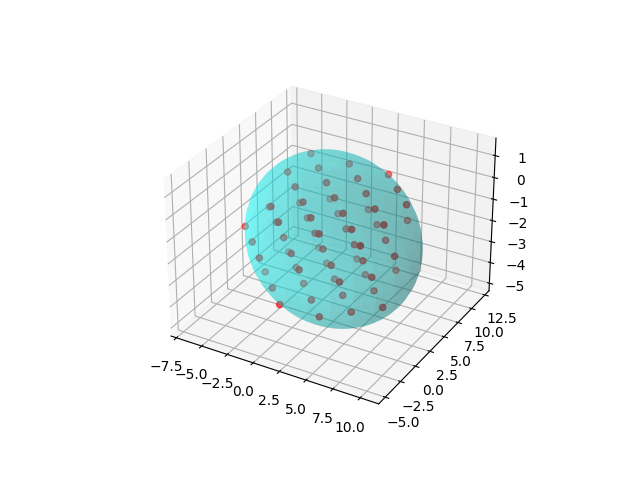

In [115]:
draw_ellipsoid(last_atom_list[3])